[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/09_data_aggregation/09_9_Exercises.ipynb)

# 09.9: Exercises

These exercises cover the full range of tools from module 09: multi-key groupby, `agg()` with named aggregations, `transform()`, `filter()`, and `pivot_table()`. All exercises use the Gapminder dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/jennybc/gapminder/main/inst/extdata/gapminder.tsv"
df = pd.read_csv(url, sep="\t")
df2007 = df[df["year"] == 2007].copy().reset_index(drop=True)

print(f"Full dataset: {df.shape}")
print(f"2007 snapshot: {df2007.shape}")
df.head()

Full dataset: (1704, 6)
2007 snapshot: (142, 6)


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


---
## Part 1: Orientation and basic groupby

### Exercise 1

Confirm that each country appears exactly 12 times in the full dataset. Then show how many distinct countries are in each continent, sorted from most to fewest.

In [2]:
# your code here

In [3]:
#@title Solution
counts = df["country"].value_counts()
print("All countries appear exactly 12 times:", (counts == 12).all())
print()
df.groupby("continent")["country"].nunique().sort_values(ascending=False)

All countries appear exactly 12 times: True



continent
Africa      52
Asia        33
Europe      30
Americas    25
Oceania      2
Name: country, dtype: int64

### Exercise 2

Using `df2007`, compute the mean, median, and standard deviation of `lifeExp` for each continent. Return a single DataFrame sorted by mean life expectancy (descending). Round all values to one decimal place.

In [4]:
# your code here

In [5]:
#@title Solution
(
    df2007.groupby("continent")["lifeExp"]
    .agg(["mean", "median", "std"])
    .round(1)
    .sort_values("mean", ascending=False)
)

,mean,median,std
continent,,,
Oceania,80.7,80.7,0.7
Europe,77.6,78.6,3.0
Americas,73.6,72.9,4.4
Asia,70.7,72.4,8.0
Africa,54.8,52.9,9.6


### Exercise 3

Using named aggregations on `df2007`, produce a single summary table with one row per continent containing:
- `avg_life`: mean life expectancy
- `total_pop`: total population
- `avg_gdp`: mean GDP per capita
- `n_countries`: number of distinct countries

Round numeric columns to 1 decimal place and sort by `avg_life` descending.

In [6]:
# your code here

In [7]:
#@title Solution
(
    df2007.groupby("continent").agg(
        avg_life    = ("lifeExp",   "mean"),
        total_pop   = ("pop",       "sum"),
        avg_gdp     = ("gdpPercap", "mean"),
        n_countries = ("country",   "nunique")
    )
    .round(1)
    .sort_values("avg_life", ascending=False)
)

,avg_life,total_pop,avg_gdp,n_countries
continent,,,,
Oceania,80.7,24549947,29810.2,2
Europe,77.6,586098529,25054.5,30
Americas,73.6,898871184,11003.0,25
Asia,70.7,3811953827,12473.0,33
Africa,54.8,929539692,3089.0,52


---
## Part 2: Multiple groupby keys

### Exercise 4

Using the full dataset, group by `["continent", "year"]` and compute the mean GDP per capita. Then call `unstack("year")` and display the result rounded to 0 decimal places. Which continent shows the largest absolute increase in mean GDP from 1952 to 2007?

In [8]:
# your code here

In [9]:
#@title Solution
wide = (
    df.groupby(["continent", "year"])["gdpPercap"]
    .mean()
    .unstack("year")
    .round(0)
)
print(wide)
print()
gain = wide[2007] - wide[1952]
print("Largest absolute GDP gain:")
print(gain.sort_values(ascending=False))
# Oceania (about $19,500) narrowly beats Europe (about $19,400).

year          1952     1957     1962     1967     1972     1977     1982  \
continent                                                                  
Africa      1253.0   1385.0   1598.0   2050.0   2340.0   2586.0   2482.0   
Americas    4079.0   4616.0   4902.0   5668.0   6491.0   7352.0   7507.0   
Asia        5195.0   5788.0   5729.0   5971.0   8187.0   7791.0   7434.0   
Europe      5661.0   6963.0   8365.0  10144.0  12480.0  14284.0  15618.0   
Oceania    10298.0  11599.0  12696.0  14495.0  16417.0  17284.0  18555.0   

year          1987     1992     1997     2002     2007  
continent                                               
Africa      2283.0   2282.0   2379.0   2599.0   3089.0  
Americas    7793.0   8045.0   8889.0   9288.0  11003.0  
Asia        7608.0   8640.0   9834.0  10174.0  12473.0  
Europe     17214.0  17062.0  19077.0  21712.0  25054.0  
Oceania    20448.0  20894.0  24024.0  26939.0  29810.0  

Largest absolute GDP gain:
continent
Oceania     19512.0
Europe    

### Exercise 5

Find the 5 countries with the highest life expectancy in 2007. Show their country name, continent, and life expectancy.

In [10]:
# your code here

In [11]:
#@title Solution
df2007.nlargest(5, "lifeExp")[["country", "continent", "lifeExp"]]

,country,continent,lifeExp
66,Japan,Asia,82.603
55,"Hong Kong, China",Asia,82.208
57,Iceland,Europe,81.757
123,Switzerland,Europe,81.701
5,Australia,Oceania,81.235


### Exercise 6

Find the 5 countries with the lowest GDP per capita in 2007. Show their country name, continent, and GDP per capita rounded to 2 decimal places.

In [12]:
# your code here

In [13]:
#@title Solution
result = df2007.nsmallest(5, "gdpPercap")[["country", "continent", "gdpPercap"]].copy()
result["gdpPercap"] = result["gdpPercap"].round(2)
result

,country,continent,gdpPercap
27,"Congo, Dem. Rep.",Africa,277.55
74,Liberia,Africa,414.51
17,Burundi,Africa,430.07
141,Zimbabwe,Africa,469.71
52,Guinea-Bissau,Africa,579.23


---
## Part 3: `transform()`

### Exercise 7

Using the full dataset (all years), add a column `continent_avg_gdp` that holds the continent-level mean GDP per capita for each row, computed across all years. Then show the first 10 rows of `country`, `continent`, `year`, `gdpPercap`, and `continent_avg_gdp`.

In [14]:
# your code here

In [15]:
#@title Solution
df_ex7 = df.copy()
df_ex7["continent_avg_gdp"] = df_ex7.groupby("continent")["gdpPercap"].transform("mean")
df_ex7[["country", "continent", "year", "gdpPercap", "continent_avg_gdp"]].head(10).round(1)

,country,continent,year,gdpPercap,continent_avg_gdp
0,Afghanistan,Asia,1952,779.4,7902.2
1,Afghanistan,Asia,1957,820.9,7902.2
2,Afghanistan,Asia,1962,853.1,7902.2
3,Afghanistan,Asia,1967,836.2,7902.2
4,Afghanistan,Asia,1972,740.0,7902.2
5,Afghanistan,Asia,1977,786.1,7902.2
6,Afghanistan,Asia,1982,978.0,7902.2
7,Afghanistan,Asia,1987,852.4,7902.2
8,Afghanistan,Asia,1992,649.3,7902.2
9,Afghanistan,Asia,1997,635.3,7902.2


### Exercise 8

Using `df2007`, compute each country's deviation from its continent average GDP per capita (`gdpPercap - continent_mean_gdp`). Then find the country in each continent that was furthest above its continental average in 2007. Return one row per continent.

In [16]:
# your code here

In [17]:
#@title Solution
df_ex8 = df2007.copy()
df_ex8["continent_avg_gdp"] = df_ex8.groupby("continent")["gdpPercap"].transform("mean")
df_ex8["gdp_vs_continent"] = df_ex8["gdpPercap"] - df_ex8["continent_avg_gdp"]

(
    df_ex8.loc[df_ex8.groupby("continent")["gdp_vs_continent"].idxmax()]
    [["continent", "country", "gdpPercap", "continent_avg_gdp", "gdp_vs_continent"]]
    .round(1)
    .sort_values("continent")
)

,continent,country,gdpPercap,continent_avg_gdp,gdp_vs_continent
45,Africa,Gabon,13206.5,3089.0,10117.5
134,Americas,United States,42951.7,11003.0,31948.6
71,Asia,Kuwait,47307.0,12473.0,34834.0
95,Europe,Norway,49357.2,25054.5,24302.7
5,Oceania,Australia,34435.4,29810.2,4625.2


### Exercise 9

Compute a within-continent z-score for `lifeExp` in `df2007`: subtract each country's continent mean and divide by the continent standard deviation. Store the result in a column `life_zscore`. Which country had the highest z-score (most above its continental peers) in 2007?

In [18]:
# your code here

In [19]:
#@title Solution
df_ex9 = df2007.copy()
df_ex9["life_zscore"] = (
    (df_ex9["lifeExp"] - df_ex9.groupby("continent")["lifeExp"].transform("mean"))
    / df_ex9.groupby("continent")["lifeExp"].transform("std")
)
df_ex9.nlargest(5, "life_zscore")[["country", "continent", "lifeExp", "life_zscore"]].round(2)

,country,continent,lifeExp,life_zscore
105,Reunion,Africa,76.44,2.25
75,Libya,Africa,73.95,1.99
130,Tunisia,Africa,73.92,1.98
81,Mauritius,Africa,72.80,1.87
2,Algeria,Africa,72.30,1.82


---
## Part 4: `filter()`

### Exercise 10

Using the full dataset and `groupby("country").filter()`, keep only countries where life expectancy exceeded 50 in every year from 1977 onward. How many rows remain? How many distinct countries?

In [20]:
# your code here

In [21]:
#@title Solution
df_recent = df[df["year"] >= 1977].copy()
consistent = df_recent.groupby("country").filter(
    lambda g: g["lifeExp"].min() > 50
)
print(f"Rows remaining: {len(consistent)}")
print(f"Distinct countries: {consistent['country'].nunique()}")

Rows remaining: 700
Distinct countries: 100


### Exercise 11

Using `df2007` and `groupby("continent").filter()`, keep only continents where the mean GDP per capita exceeded $10,000. Then compute the average population of those continents across all years (using the full dataset filtered to those same continents).

In [22]:
# your code here

In [23]:
#@title Solution
rich_continents = (
    df2007.groupby("continent")
    .filter(lambda g: g["gdpPercap"].mean() > 10000)
    ["continent"].unique()
)
print("Qualifying continents:", rich_continents.tolist())

(
    df[df["continent"].isin(rich_continents)]
    .groupby("continent")["pop"]
    .mean()
    .round(0)
)

Qualifying continents: ['Asia', 'Europe', 'Americas', 'Oceania']


continent
Americas    24504795.0
Asia        77038722.0
Europe      17169765.0
Oceania      8874672.0
Name: pop, dtype: float64

---
## Part 5: `pivot_table()` and visualization

### Exercise 12

Build a continent × year pivot table of mean life expectancy using `pd.pivot_table()`. Add `margins=True` so overall means appear in the `All` row and column. Round to 1 decimal place.

In [24]:
# your code here

In [25]:
#@title Solution
pd.pivot_table(
    df,
    values="lifeExp",
    index="continent",
    columns="year",
    aggfunc="mean",
    margins=True,
    margins_name="All"
).round(1)

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007,All
continent,,,,,,,,,,,,,
Africa,39.1,41.3,43.3,45.3,47.5,49.6,51.6,53.3,53.6,53.6,53.3,54.8,48.9
Americas,53.3,56.0,58.4,60.4,62.4,64.4,66.2,68.1,69.6,71.2,72.4,73.6,64.7
Asia,46.3,49.3,51.6,54.7,57.3,59.6,62.6,64.9,66.5,68.0,69.2,70.7,60.1
Europe,64.4,66.7,68.5,69.7,70.8,71.9,72.8,73.6,74.4,75.5,76.7,77.6,71.9
Oceania,69.3,70.3,71.1,71.3,71.9,72.9,74.3,75.3,76.9,78.2,79.7,80.7,74.3
All,49.1,51.5,53.6,55.7,57.6,59.6,61.5,63.2,64.2,65.0,65.7,67.0,59.5


### Exercise 13

Build the same continent × year life expectancy pivot table (without margins). Pass it to `sns.heatmap()` with annotations and a sequential colormap of your choice. Add a title.

In [26]:
# your code here

Text(103.75, 0.5, 'Continent')

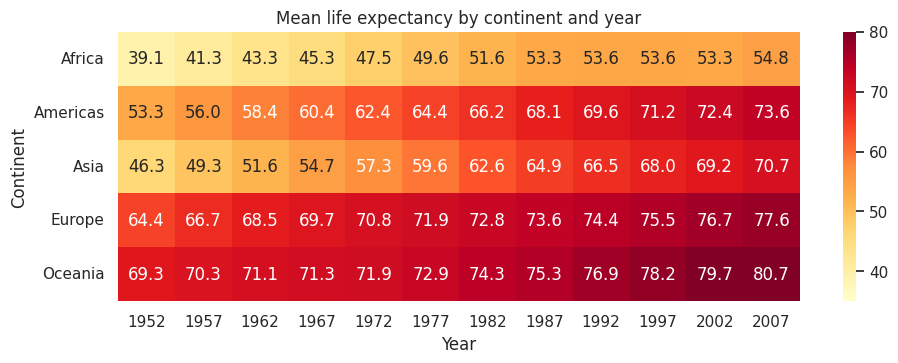

In [27]:
#@title Solution
pt = pd.pivot_table(
    df,
    values="lifeExp",
    index="continent",
    columns="year",
    aggfunc="mean"
).round(1)

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(pt, annot=True, fmt=".1f", cmap="YlOrRd", vmin=35, vmax=80, ax=ax)
ax.set_title("Mean life expectancy by continent and year")
ax.set_xlabel("Year")
ax.set_ylabel("Continent")

### Exercise 14 (Challenge)

For each continent, find the country that experienced the largest **increase** in life expectancy between 1952 and 2007. Return a DataFrame with one row per continent showing the continent name, the country name, and the gain in years (rounded to 1 decimal place), sorted by gain descending.

In [28]:
# your code here

In [29]:
#@title Solution
life_1952 = df[df["year"] == 1952][["country", "continent", "lifeExp"]].rename(columns={"lifeExp": "life_1952"})
life_2007 = df[df["year"] == 2007][["country", "lifeExp"]].rename(columns={"lifeExp": "life_2007"})

# merge() is previewed here; module 10 teaches it properly alongside SQL JOIN
gains = life_1952.merge(life_2007, on="country")
gains["gain"] = (gains["life_2007"] - gains["life_1952"]).round(1)

best_per_continent = (
    gains.loc[gains.groupby("continent")["gain"].idxmax()]
    [["continent", "country", "gain"]]
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
best_per_continent

,continent,country,gain
0,Asia,Oman,38.1
1,Africa,Libya,31.2
2,Americas,Nicaragua,30.6
3,Europe,Turkey,28.2
4,Oceania,Australia,12.1


## Module 09 complete

You have now practiced the full groupby toolkit: multi-key groupby with the MultiIndex, `agg()` with named aggregations for building summary tables, `transform()` for adding group-level statistics back to every row, `filter()` for keeping or removing entire groups by condition, and `pivot_table()` for producing wide-format summaries directly. These tools answer the questions that a single-key groupby cannot: how a group changes over time, how each member of a group compares to its peers, and which groups meet a threshold worth analyzing further.

Module 10 introduces a second language for the same ideas. SQL has been the standard tool for querying tabular data in databases for decades, and pandas borrows its vocabulary directly: `WHERE` maps to boolean indexing, `GROUP BY` maps to `groupby()`, and `JOIN` maps to `merge()`. Working through both syntaxes side by side sharpens each one, because you can see exactly where they agree and where they differ.